# Clustering Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [ ]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [215]:
tracks_df = pd.read_csv("../datasets/tracks_prepared.csv")
artists_df = pd.read_csv("../datasets/artists_prepared.csv")

### Select which features will be used

In [216]:
# Print all feature names
tracks_original_features = tracks_df.columns.tolist()
print(tracks_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(tracks_original_features)}")

['id_artist', 'name_artist', 'title', 'featured_artists', 'language', 'stats_pageviews', 'swear_IT', 'swear_EN', 'swear_IT_words', 'swear_EN_words', 'year', 'month', 'day', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type', 'track_number', 'duration_ms', 'explicit', 'popularity', 'outlier', 'outlier_score', 'arrapante', 'arrapare', 'arrapato', 'bagascia', 'bastardi', 'bastardo', 'battona', 'bernarda', 'bischero', 'blowjob', 'bocchinaro', 'bocchino', 'bombare', 'cacare', 'cacata', 'cacca', 'cagare', 'cagata', 'cagna', 'cappella', 'cazzata', 'cazzeggiare', 'cazzeggio', 'cazzi', 'cazzo', 'cazzone', 'cazzuto', 'cesso', 'checca', 'chiappa', 'chiavare', 'chiavata', 'cogliona', 'coglionata', 'coglione', 'coglioni', 'controcazzi', 'controcoglioni', 'cornuto', 'cozza', 'cretina', 'cretini', 'cretino', 'culattone', 

In [217]:
# Print all feature names
artists_original_features = artists_df.columns.tolist()
print(artists_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(artists_original_features)}")

['id_author', 'name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'region', 'country', 'latitude', 'longitude', 'starting_age', 'artist_age', 'birth_year', 'artist_collab_rate']

Total number of features: 18


## Features Selection

We tried to select features that capture different aspects, like: linguistic, audio, popularity, etc.

In [218]:
selected_features = [
    # linguistic / lyrics
    'n_tokens',

    # audio features
    'centroid',
    'rolloff',
    'loudness',

    # popularity
    'popularity', 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration', 'swear_ratio', 'aggressiveness'
]

In [219]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [220]:
# Check for NaN values
print(X.isna().sum())

n_tokens               0
centroid               0
rolloff                0
loudness               0
popularity             0
relative_popularity    0
has_collaboration      0
swear_ratio            0
aggressiveness         0
dtype: int64


**log1p transformation**: applying log to numeric skewed features

Skewness of continuous features:
 popularity             15.181913
swear_ratio             5.044610
n_tokens                1.173797
rolloff                 1.065049
relative_popularity     0.265483
aggressiveness          0.082765
centroid                0.079253
loudness               -0.076856
dtype: float64


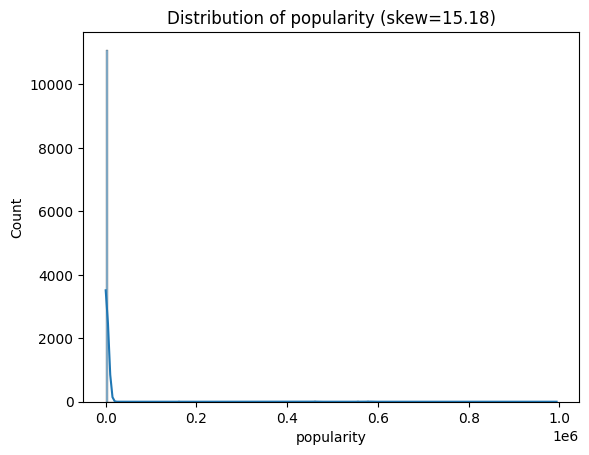

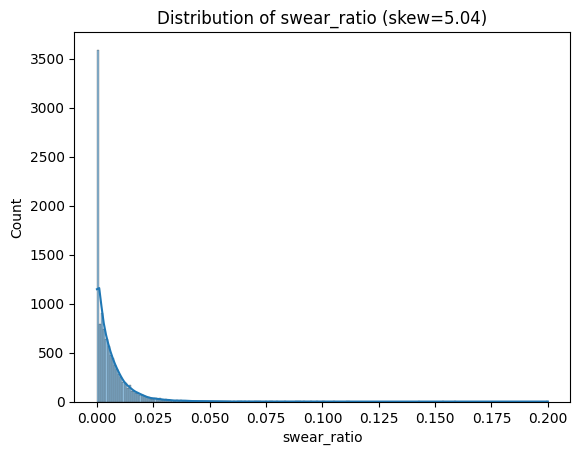

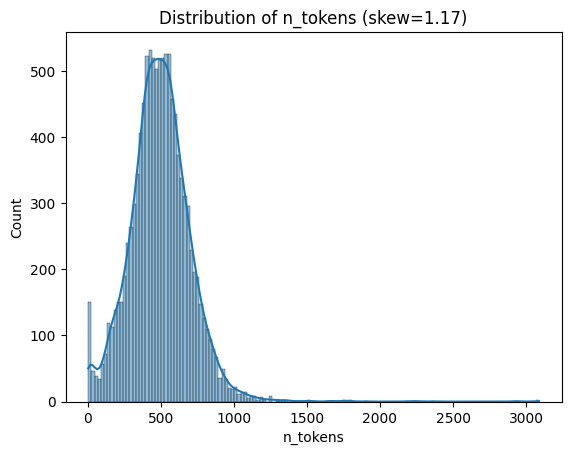

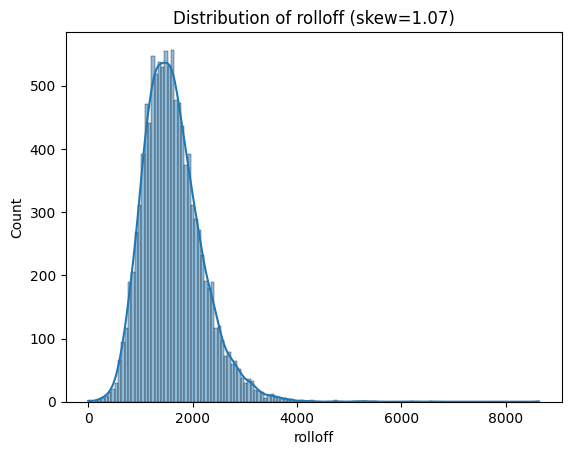

Skewness after log1p transformation:
 swear_ratio            4.678938
popularity             2.883568
relative_popularity    0.265483
aggressiveness         0.082765
centroid               0.079253
loudness              -0.076856
rolloff               -1.305208
n_tokens              -3.454655
dtype: float64


In [221]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is our selected features for clustering

# Step 0: Filter out binary and one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 1].index  # threshold for positive skew
for col in high_skew:
    plt.figure()
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
    plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [222]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [223]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

## K-Means

Train multiple KMeans models

In [ ]:

from tqdm import tqdm


def run_kmeans_multiple(X, k_list, n_init=10, max_iter=300):
    """
    Train KMeans for multiple values of K.
    Returns:
        - list of KMeans models
        - SSE (inertia) list
        - Silhouette score list
    """
    kmeans_models = []
    sse_list = []
    silhouette_list = []

    for k in tqdm(k_list):
        kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter)
        kmeans.fit(X)

        kmeans_models.append(kmeans)
        sse_list.append(kmeans.inertia_)

        # Compute silhouette score if possible
        try:
            sil = silhouette_score(X, kmeans.labels_)
        except:
            sil = np.nan

        silhouette_list.append(sil)

        print(f"K={k}  | SSE={kmeans.inertia_:.2f} | Silhouette={sil:.4f}")

    return kmeans_models, sse_list, silhouette_list


Run KMeans for k = 2 to 16

In [225]:
k_list = list(range(2, 17))

kmeans_list, sse_list, silhouette_list = run_kmeans_multiple(
    X_minmax,
    k_list,
    n_init=10,
    max_iter=300
)


  7%|▋         | 1/15 [00:07<01:45,  7.54s/it]

K=2  | SSE=902.27 | Silhouette=0.6614


 13%|█▎        | 2/15 [00:13<01:29,  6.89s/it]

K=3  | SSE=702.69 | Silhouette=0.4030


 20%|██        | 3/15 [00:19<01:16,  6.36s/it]

...

K=14  | SSE=365.43 | Silhouette=0.1773


 93%|█████████▎| 14/15 [01:25<00:05,  6.00s/it]

K=15  | SSE=360.32 | Silhouette=0.1746


100%|██████████| 15/15 [01:30<00:00,  6.04s/it]

K=16  | SSE=344.35 | Silhouette=0.1720


Plot SSE (Elbow Method)

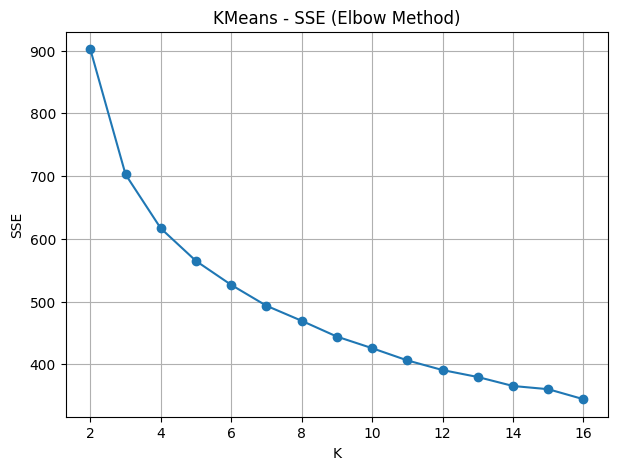

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(k_list, sse_list, marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('KMeans - SSE (Elbow Method)')
plt.grid(True)
plt.show()


Plot Silhouette Scores

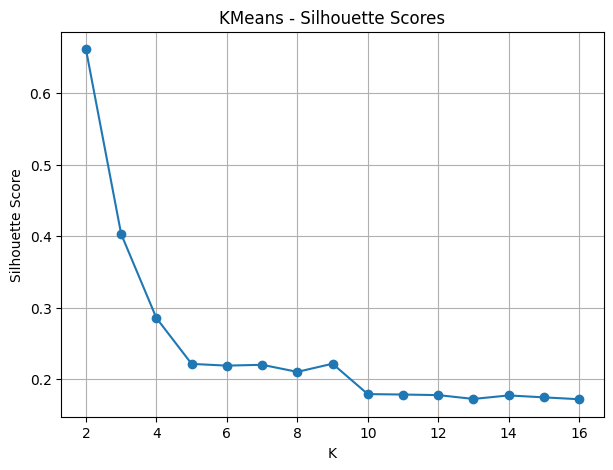

In [227]:
plt.figure(figsize=(7,5))
plt.plot(k_list, silhouette_list, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('KMeans - Silhouette Scores')
plt.grid(True)
plt.show()


Choose the best K after observing the graphs

In [242]:
best_k = 3
best_kmeans = kmeans_list[k_list.index(best_k)]
final_kmeans_clusters = best_kmeans.labels_

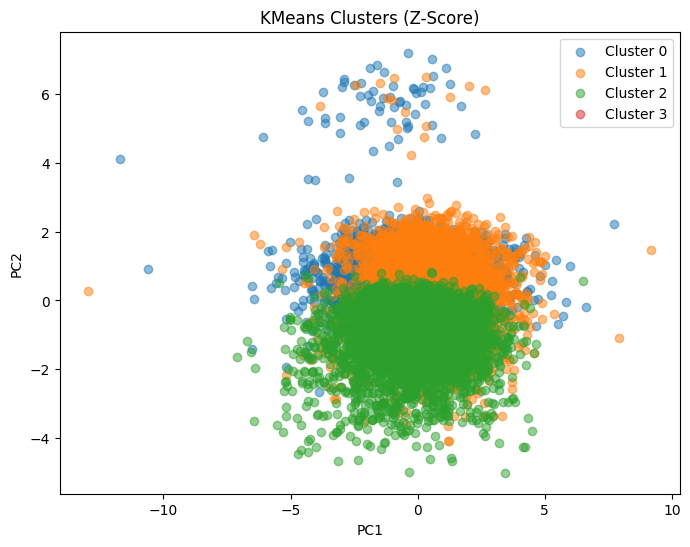

In [243]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[final_kmeans_clusters == cluster, 0],
        X_pca[final_kmeans_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Z-Score)')
plt.legend()
plt.show()


Analysis of Final K-Means

Cluster size distribution

Cluster sizes: [np.int64(3974), np.int64(3532), np.int64(3660)]


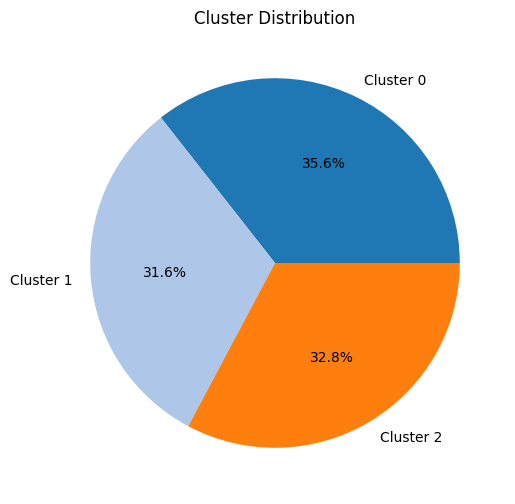

In [244]:
clusters = final_kmeans_clusters

n_clusters = len(np.unique(clusters))

# Count how many points per cluster
occ_list = [np.sum(clusters == k) for k in range(n_clusters)]

print("Cluster sizes:", occ_list)

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    occ_list,
    labels=[f"Cluster {k}" for k in range(n_clusters)],
    colors=sns.color_palette("tab20", n_clusters),
    autopct='%1.1f%%'
)
plt.title("Cluster Distribution")
plt.show()


Pairplot

In [245]:
tracks_clusters = tracks_df.copy()
tracks_clusters['cluster'] = clusters

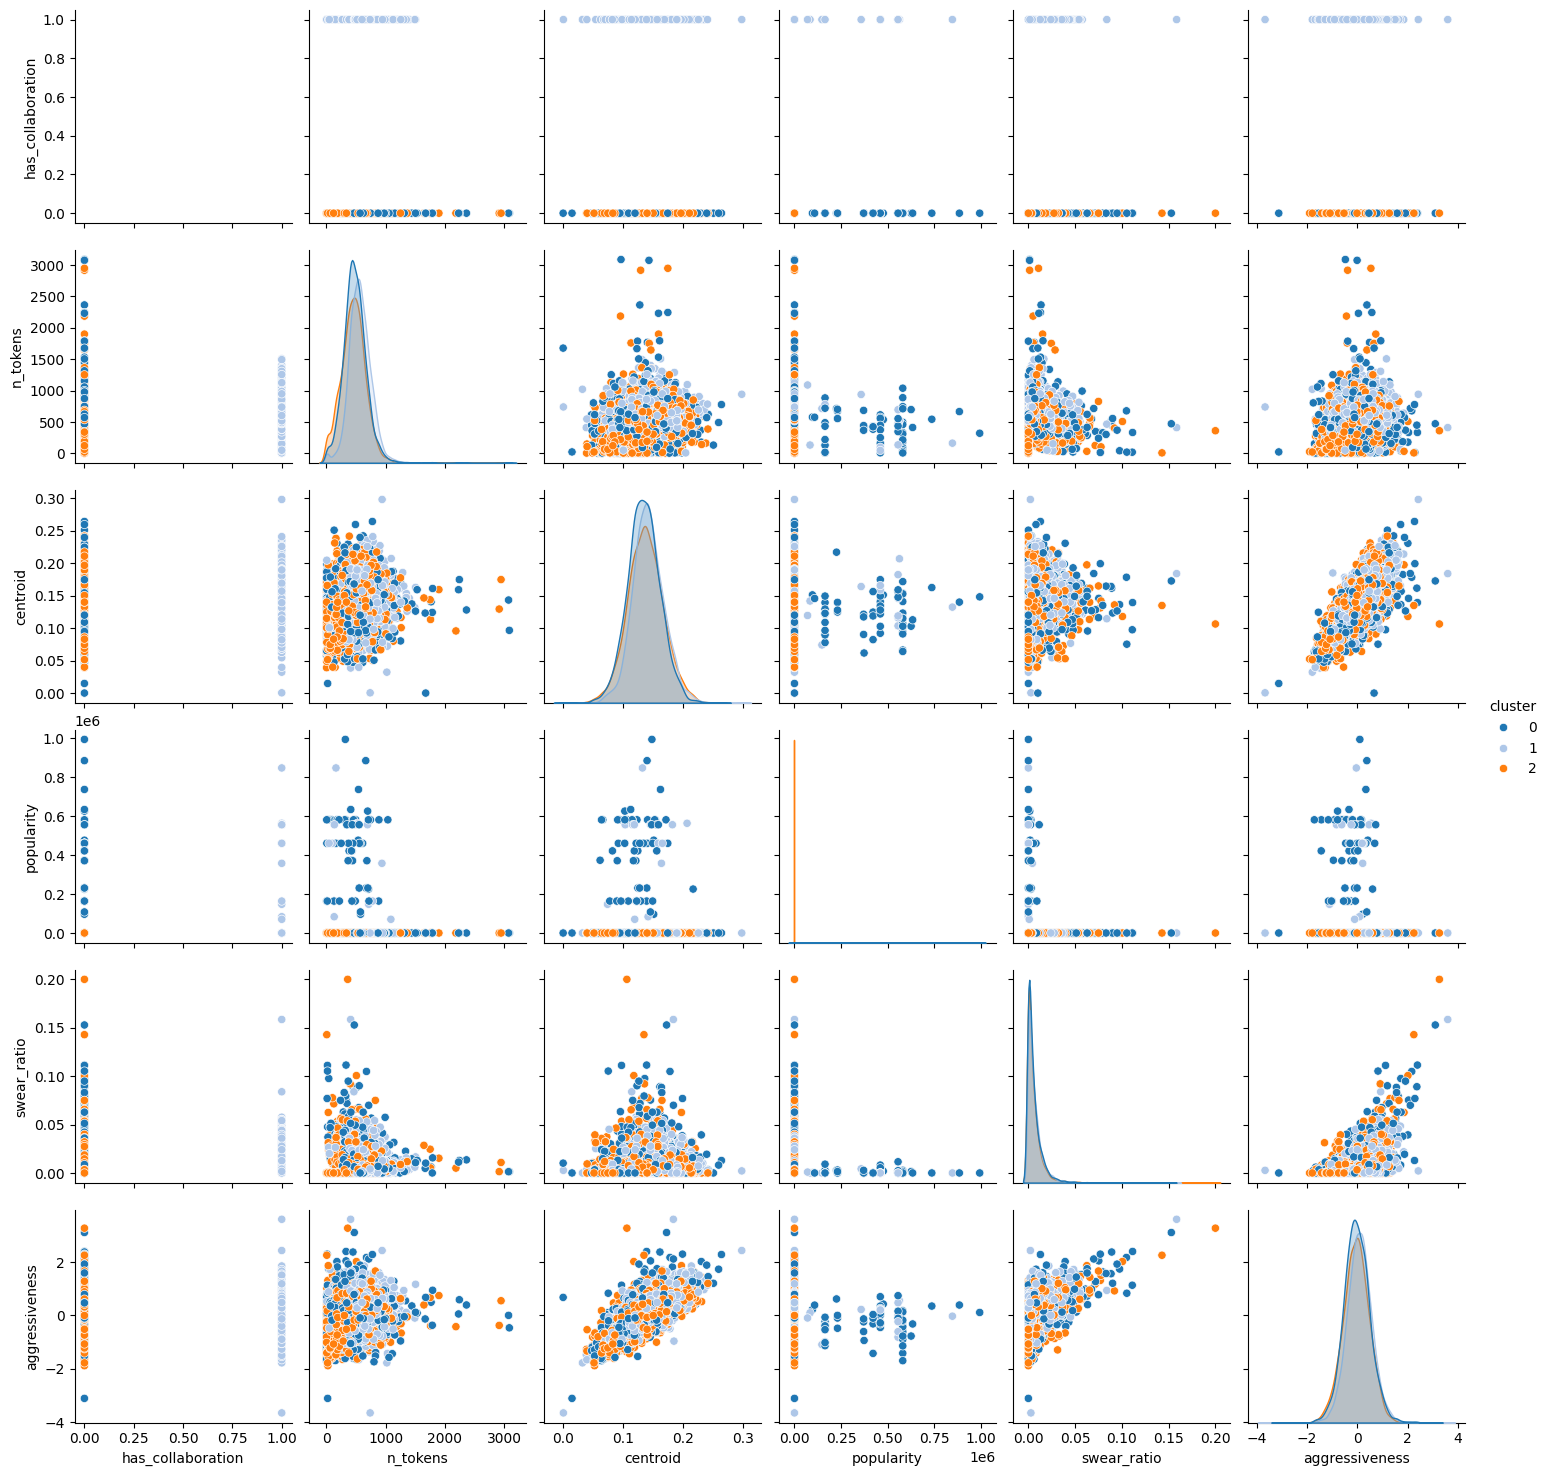

In [247]:
pairplot_features = [
    'has_collaboration',
    'n_tokens', 
    'centroid', 
    'popularity', 
    'swear_ratio',  
    'aggressiveness',
    'cluster'
]

sns.pairplot(
    tracks_clusters[pairplot_features],
    hue="cluster",
    palette=sns.color_palette("tab20", n_clusters)
)
plt.show()


PCA in 3D

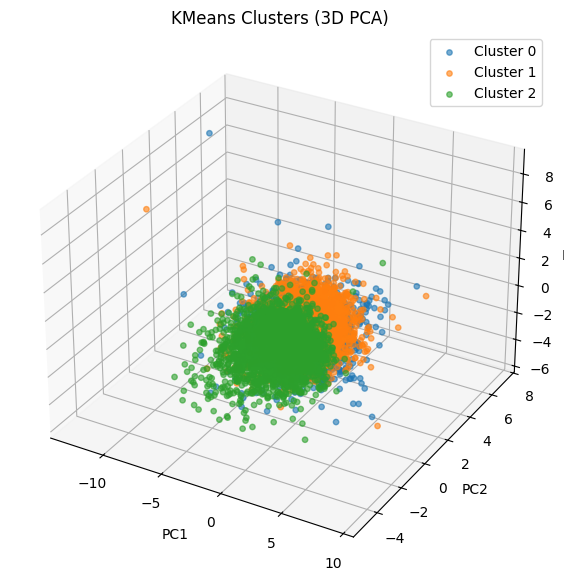

In [248]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca3 = pca.fit_transform(X_zscore)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for k in range(n_clusters):
    ax.scatter(
        X_pca3[clusters == k, 0],
        X_pca3[clusters == k, 1],
        X_pca3[clusters == k, 2],
        s=15,
        alpha=0.6,
        label=f"Cluster {k}"
    )

ax.set_title("KMeans Clusters (3D PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()


In [249]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_zscore = kmeans.fit_predict(X_zscore)

In [250]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_clusters_minmax = kmeans.fit_predict(X_minmax)

### Visualization

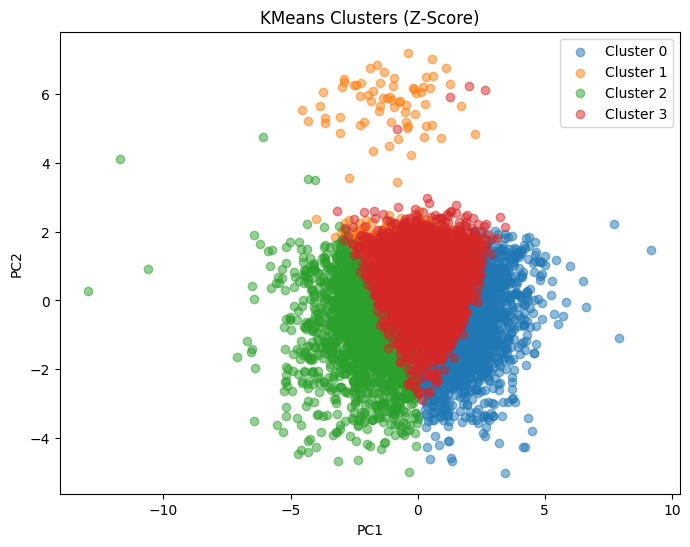

In [251]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_zscore == cluster, 0],
        X_pca[clusters_zscore == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Z-Score)')
plt.legend()
plt.show()


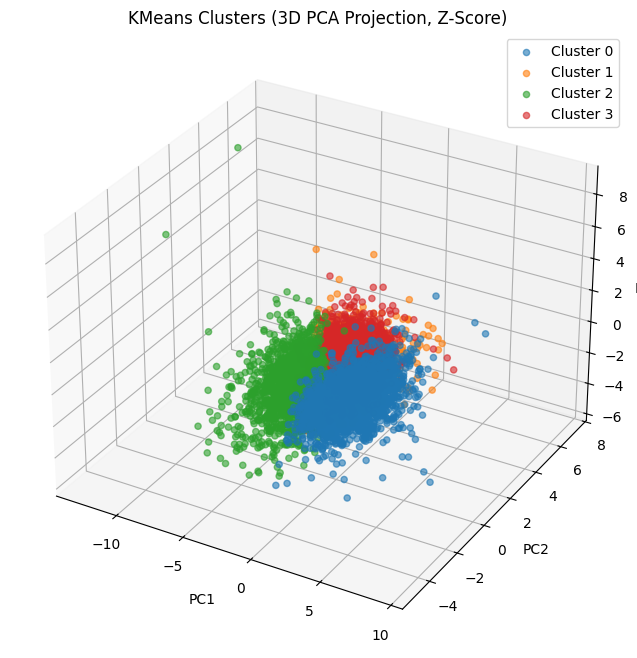

In [252]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_zscore)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_zscore == cluster, 0],
        X_pca_3d[clusters_zscore == cluster, 1],
        X_pca_3d[clusters_zscore == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, Z-Score)')
ax.legend()

plt.show()


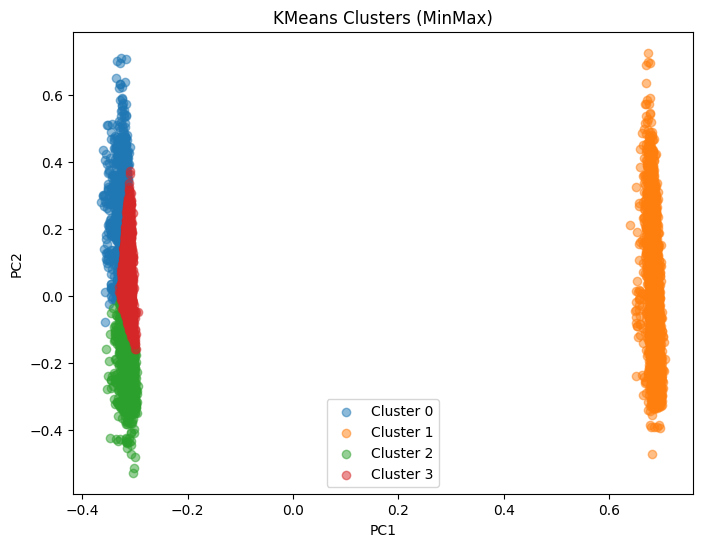

In [253]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[kmeans_clusters_minmax == cluster, 0],
        X_pca[kmeans_clusters_minmax == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (MinMax)')
plt.legend()
plt.show()


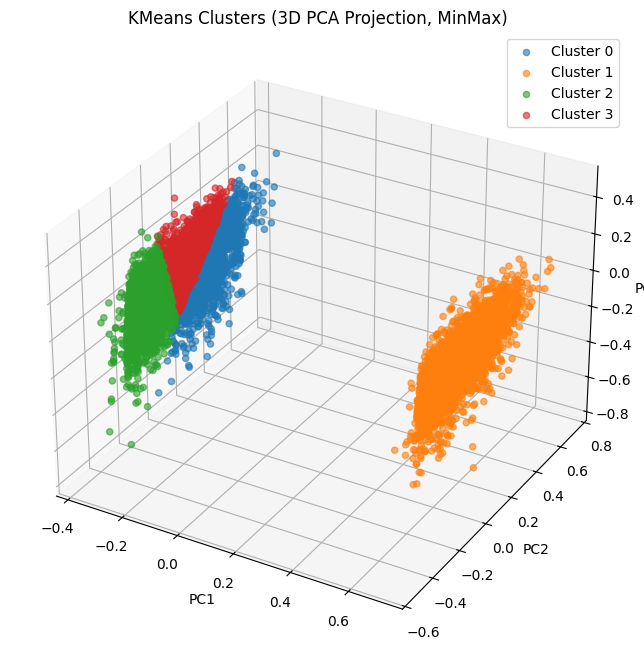

In [254]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots even if unused
import numpy as np

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_minmax)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[kmeans_clusters_minmax == cluster, 0],
        X_pca_3d[kmeans_clusters_minmax == cluster, 1],
        X_pca_3d[kmeans_clusters_minmax == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, MinMax)')
ax.legend()

plt.show()


### Evaluation

In [255]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_zscore, clusters_zscore)
print(f'Silhouette Score (Zscore): {score:.3f}')


Silhouette Score (Zscore): 0.149


In [256]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_minmax, kmeans_clusters_minmax)
print(f'Silhouette Score (MinMax): {score:.3f}')


Silhouette Score (MinMax): 0.345


See which are the features that were most important for the clustering

In [257]:
# Get cluster centroids in scaled space
centroids = kmeans.cluster_centers_

# Create a DataFrame for easier reading
centroids_df = pd.DataFrame(centroids, columns=X.columns)

# Compute variance of each column across cluster centers
feature_importance = centroids_df.var(axis=0).sort_values(ascending=False)

print("Feature importance based on centroid variance:")
print(feature_importance)


Feature importance based on centroid variance:
has_collaboration      0.250000
relative_popularity    0.031688
popularity             0.002467
n_tokens               0.001649
loudness               0.001531
centroid               0.000941
aggressiveness         0.000723
rolloff                0.000052
swear_ratio            0.000009
dtype: float64


In [258]:
centroids_df


,n_tokens,centroid,rolloff,loudness,popularity,relative_popularity,has_collaboration,swear_ratio,aggressiveness
0,0.640144,0.421475,0.800130,0.234951,0.166734,0.572367,1.609823e-15,0.027756,0.464651
1,0.730325,0.475028,0.812036,0.312072,0.242282,0.319280,1.000000e+00,0.034366,0.515464
2,0.694092,0.439020,0.802131,0.282017,0.287078,0.141520,1.776357e-15,0.031239,0.491801
3,0.721398,0.487330,0.814693,0.322097,0.230553,0.386058,1.998401e-15,0.034088,0.524828
